# Parameter-Timescale Relationship Analysis System

## Overview
This notebook provides a comprehensive, efficient system for analyzing the relationship between model parameters (w_EE, w_EI) and timescales across all particles. **Now supports both homogeneous and heterogeneous parameter sets.**

## Key Features

### 🔄 **Flexible Parameter Support**
- **Homogeneous Parameters**: Single values per parameter `[w_EI, w_EE, G]`
- **Heterogeneous Parameters**: Bias + coefficient per parameter `[w_EI_bias, w_EI_coeff, w_EE_bias, w_EE_coeff, G]`
- Automatic parameter type detection
- Easy switching between parameter types

### 🚀 **Efficient Parallel Processing**
- Uses `joblib` for multi-core processing
- Batch processing to manage memory efficiently 
- Progress tracking and error handling
- Automatic filtering of unstable particles

### 💾 **Minimal Data Structure**
- Only stores essential data: `[w_EE, w_EI, timescale, particle_id]`
- Memory efficient for large datasets
- Easy to load and analyze

### 📊 **Comprehensive Visualization**  
- Parameter vs timescale scatter plots with trend lines
- Parameter space visualization colored by timescale
- Distribution plots and correlation matrices
- Statistical summaries with correlation coefficients

## How to Use

1. **Parameter Selection**: Execute cell 2 to choose between homogeneous/heterogeneous parameters
2. **Test Both Types**: Execute cell 14 to verify both parameter types work correctly
3. **Test Run**: Execute cell 9 first with a small subset to verify everything works
4. **Full Analysis**: Run cell 10 to process ALL particles (may take time depending on your system)
5. **Visualization**: Execute cells 11-12 to generate comprehensive plots and analysis
6. **Results**: All data and plots are automatically saved to `/home/frank/HBNM/outputs/`

## Parameter Types

### Homogeneous Parameters
```python
model.set('w_EI', (theta_homogeneous[0, particle_id], ))
model.set('w_EE', (theta_homogeneous[1, particle_id], ))
model.set('G', (theta_homogeneous[2, particle_id], ))
```

### Heterogeneous Parameters  
```python
model.set('w_EI', (theta_heterogeneous[0, particle_id], theta_heterogeneous[1, particle_id]))
model.set('w_EE', (theta_heterogeneous[2, particle_id], theta_heterogeneous[3, particle_id]))
model.set('G', (theta_heterogeneous[4, particle_id], ))
```

## Performance Notes
- Processing time scales with number of particles and available CPU cores
- Batch size can be adjusted based on available memory
- Results are automatically saved for future use
- Unstable particles are automatically filtered out

## Output Files
- `parameter_timescale_dataset.npy`: Raw dataset
- `parameter_timescale_relationships.png`: Comprehensive plots
- `correlation_matrix.csv`: Statistical correlations


In [1]:
# Imports
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm
from experiments.Model_Picker.picker_utils import find_fixed_point, compute_jacobian, analyze_jacobian_structure, eigen_analysis, analyze_eigenspectrum
from tqdm import tqdm
import pandas as pd

# Define data object
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 
myelin = np.load('/home/frank/HBNM/data/heterogeneity_vectors/raw/myelin_raw.npy').reshape(180)

# Find default model parameters
fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
theta_homogeneous = fin['apprx_posterior_homogeneous'][:]
fin.close()

In [2]:
# Parameter type detection function
def detect_parameter_type(theta):
    """
    Detect whether parameters are homogeneous or heterogeneous based on shape.
    
    Parameters:
    -----------
    theta : array
        Parameter array
        
    Returns:
    --------
    str : 'homogeneous' or 'heterogeneous'
    """
    if theta.shape[0] == 3 or theta.shape[0] == 4:  # [w_EI, w_EE, G]
        return 'homogeneous'
    elif theta.shape[0] == 5 or theta.shape[0] == 6:  # [w_EI_bias, w_EI_coeff, w_EE_bias, w_EE_coeff, G]
        return 'heterogeneous'
    else:
        raise ValueError(f"Unexpected parameter shape: {theta.shape}")

# Helper functions for timescale analysis
def compute_excitatory_timescales(eigenvalues, eigenvectors, n_regions=180):
    """
    Compute timescales for excitatory firing rate dynamics
    
    The excitatory firing rates r_E depend on both S_E and S_I through:
    r_E = φ_E(I_E) where I_E = f(S_E, S_I)
    
    We extract the excitatory component from each eigenmode.
    """
    # Only consider stable modes (Re(λ) < 0)
    stable_mask = eigenvalues.real < 0
    stable_eigenvals = eigenvalues[stable_mask]
    stable_eigenvecs = eigenvectors[:, stable_mask]
    
    # Modal timescales
    modal_timescales = -1.0 / stable_eigenvals.real
    
    # Extract ONLY the excitatory components (indices 0-179)
    excitatory_eigenvecs = stable_eigenvecs[:n_regions, :]  # First 180 rows
    
    # For each region, compute participation-weighted timescale
    regional_timescales = np.zeros(n_regions)
    
    for region in range(n_regions):
        # Weight by squared magnitude of excitatory eigenvector component
        region_weights = np.abs(excitatory_eigenvecs[region, :])**2
        
        # Compute weighted average timescale (only excitatory contribution)
        if np.sum(region_weights) > 0:
            regional_timescales[region] = np.average(modal_timescales, weights=region_weights)
        else:
            regional_timescales[region] = np.nan
            
    return regional_timescales, modal_timescales


### **Define Custom Models Here**

In [3]:
# # Load custom map (overriedes the default params)
# custom_path = data.load('Homogenous/iteration_20.hdf5', from_output=True)
# theta_custom = custom_path['theta'][:]
# custom_path.close()

# # # Load map
# # custom_map = np.load('/home/frank/HBNM/data/heterogeneity_vectors/linearized/dopamine_linearized.npy')

# # hmap = custom_map
# invert_flag = False

### **Parameter Type Selection and Information**

In [4]:
# Parameter Type Selection and Information
# ========================================
# This notebook now works with both homogeneous and heterogeneous parameters.
# 
# HOMOGENEOUS PARAMETERS:
# - Shape: (3, n_particles) 
# - Format: [w_EI, w_EE, G]
# - Usage: model.set('w_EI', (theta_homogeneous[0, particle_id], ))
#          model.set('w_EE', (theta_homogeneous[1, particle_id], ))  
#          model.set('G', (theta_homogeneous[2, particle_id], ))
#
# HETEROGENEOUS PARAMETERS:
# - Shape: (5, n_particles)
# - Format: [w_EI_bias, w_EI_coeff, w_EE_bias, w_EE_coeff, G]
# - Usage: model.set('w_EI', (theta_heterogeneous[0, particle_id], theta_heterogeneous[1, particle_id]))
#          model.set('w_EE', (theta_heterogeneous[2, particle_id], theta_heterogeneous[3, particle_id]))
#          model.set('G', (theta_heterogeneous[4, particle_id], ))

print("Available parameter types:")
print(f"theta_homogeneous shape: {theta_homogeneous.shape} -> {detect_parameter_type(theta_homogeneous)}")
print(f"theta_heterogeneous shape: {theta_heterogeneous.shape} -> {detect_parameter_type(theta_heterogeneous)}")

# Choose which parameter set to use for the analysis
# Change this line to switch between parameter types:
theta_selected = theta_heterogeneous  # or theta_homogeneous, theta_heterogeneous, theta_custom

param_type_selected = detect_parameter_type(theta_selected)
print(f"\\nSelected parameter type: {param_type_selected}")
print(f"Selected theta shape: {theta_selected.shape}")

# Display parameter ranges
print(f"\\nParameter ranges for {param_type_selected}:")
if param_type_selected == 'homogeneous':
    print(f"w_EI range: {theta_selected[0, :].min():.4f} - {theta_selected[0, :].max():.4f}")
    print(f"w_EE range: {theta_selected[1, :].min():.4f} - {theta_selected[1, :].max():.4f}")
    print(f"G range: {theta_selected[2, :].min():.4f} - {theta_selected[2, :].max():.4f}")
elif param_type_selected == 'heterogeneous':
    print(f"w_EI_bias range: {theta_selected[0, :].min():.4f} - {theta_selected[0, :].max():.4f}")
    print(f"w_EI_coeff range: {theta_selected[1, :].min():.4f} - {theta_selected[1, :].max():.4f}")
    print(f"w_EE_bias range: {theta_selected[2, :].min():.4f} - {theta_selected[2, :].max():.4f}")
    print(f"w_EE_coeff range: {theta_selected[3, :].min():.4f} - {theta_selected[3, :].max():.4f}")
    print(f"G range: {theta_selected[4, :].min():.4f} - {theta_selected[4, :].max():.4f}")


Available parameter types:
theta_homogeneous shape: (4, 1000) -> homogeneous
theta_heterogeneous shape: (6, 1000) -> heterogeneous
\nSelected parameter type: heterogeneous
Selected theta shape: (6, 1000)
\nParameter ranges for heterogeneous:
w_EI_bias range: 0.9354 - 1.1472
w_EI_coeff range: 0.1170 - 0.3149
w_EE_bias range: 2.9655 - 5.5004
w_EE_coeff range: 1.7547 - 6.0711
G range: 0.0332 - 0.1562


In [5]:
# import pandas as pd

# # Load parcellation dataframe
# parcellation_df = pd.read_csv('/home/frank/HBNM/data/parcellation_df_L.csv')


# # Check data structure dimensions
# print(f"theta_heterogeneous shape: {theta_heterogeneous.shape}")
# print(f"Number of particles available: {theta_heterogeneous.shape[1]}")
# print(f"Number of parameters: {theta_heterogeneous.shape[0]}")

# # Check parameter ranges to understand the data better
# print("\nParameter ranges:")
# print(f"w_EI_bias range: {theta_heterogeneous[0, :].min():.4f} - {theta_heterogeneous[0, :].max():.4f}")
# print(f"w_EI_coeff range: {theta_heterogeneous[1, :].min():.4f} - {theta_heterogeneous[1, :].max():.4f}")
# print(f"w_EE_bias range: {theta_heterogeneous[2, :].min():.4f} - {theta_heterogeneous[2, :].max():.4f}")  
# print(f"w_EE_coeff range: {theta_heterogeneous[3, :].min():.4f} - {theta_heterogeneous[3, :].max():.4f}")
# print(f"G range: {theta_heterogeneous[4, :].min():.4f} - {theta_heterogeneous[4, :].max():.4f}")

# print(f"\nNumber of regions: {len(parcellation_df)}")
# print(f"Estimated total data points: {theta_heterogeneous.shape[1]} particles × {len(parcellation_df)} regions = {theta_heterogeneous.shape[1] * len(parcellation_df)}")


In [6]:
# Efficient parallel processing setup
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configure for efficiency
plt.style.use('default')
sns.set_palette("husl")


In [7]:
def process_particle(particle_id, theta, sc, hmap, param_type=None, n_regions=180):
    """
    Process a single particle to extract parameter-timescale relationships.
    Works with both homogeneous and heterogeneous parameters.
    Returns minimal data structure with only essential information.
    
    Parameters:
    -----------
    particle_id : int
        ID of the particle to process
    theta : array
        Parameter array (homogeneous or heterogeneous)
    sc : array
        Structural connectivity matrix
    hmap : array
        Heterogeneity map (gradient)
    param_type : str, optional
        'homogeneous' or 'heterogeneous'. If None, will be auto-detected.
    n_regions : int
        Number of brain regions
    """
    try:
        # Auto-detect parameter type if not provided
        if param_type is None:
            param_type = detect_parameter_type(theta)
        
        # Create model for this particle
        model = Bnm(sc, gradient=hmap, map_invert_flags=[True])
        
        # Set parameters based on type
        if param_type == 'homogeneous':
            # Homogeneous: single value per parameter
            model.set('w_EI', (theta[0, particle_id], ))
            model.set('w_EE', (theta[1, particle_id], ))
            model.set('G', (theta[2, particle_id], ))
        elif param_type == 'heterogeneous':
            # Heterogeneous: bias + coefficient for w_EI and w_EE
            model.set('w_EI', (theta[0, particle_id], theta[1, particle_id]))
            model.set('w_EE', (theta[2, particle_id], theta[3, particle_id]))
            model.set('G', (theta[4, particle_id], ))
        else:
            raise ValueError(f"Unknown parameter type: {param_type}")
            
        model.moments_method
        
        # Compute dynamics
        fixed_point = find_fixed_point(model)
        J = compute_jacobian(model)
        eigen_results = eigen_analysis(J)
        
        # Check stability - skip unstable particles
        if not eigen_results['is_stable']:
            return None
            
        # Compute timescales
        regional_timescales, _ = compute_excitatory_timescales(
            eigen_results['eigenvalues'], 
            eigen_results['eigenvectors'],
            n_regions=n_regions
        )
        
        # Extract parameter values for each region
        w_EE_values = model.dmf.w_EE.copy()
        w_EI_values = model.dmf.w_EI.copy()
        
        # Create minimal data structure - only what we need
        # Shape: (n_regions, 4) = [w_EE, w_EI, timescale, particle_id]
        particle_data = np.column_stack([
            w_EE_values,
            w_EI_values, 
            regional_timescales,
            np.full(n_regions, particle_id, dtype=np.int32)
        ])
        
        return particle_data
        
    except Exception as e:
        print(f"Error processing particle {particle_id}: {str(e)}")
        return None


In [8]:
def create_parameter_timescale_dataset(theta, sc, hmap, 
                                      max_particles=None, n_jobs=-1, batch_size=50):
    """
    Create comprehensive dataset of parameter-timescale relationships across all particles.
    Works with both homogeneous and heterogeneous parameters.
    
    Parameters:
    -----------
    theta : array
        Parameter array with shape (n_params, n_particles)
        For homogeneous: (3, n_particles) - [w_EI, w_EE, G]  
        For heterogeneous: (5, n_particles) - [w_EI_bias, w_EI_coeff, w_EE_bias, w_EE_coeff, G]
    sc : array
        Structural connectivity matrix
    hmap : array  
        Heterogeneity map (gradient)
    max_particles : int, optional
        Maximum number of particles to process (for testing)
    n_jobs : int
        Number of parallel jobs (-1 for all cores)
    batch_size : int
        Process particles in batches to manage memory
        
    Returns:
    --------
    dataset : numpy array
        Array with shape (n_datapoints, 4) containing [w_EE, w_EI, timescale, particle_id]
    """
    # Detect parameter type
    param_type = detect_parameter_type(theta)
    print(f"Detected parameter type: {param_type}")
    
    n_particles = theta.shape[1]
    if max_particles is not None:
        n_particles = min(max_particles, n_particles)
    
    print(f"Processing {n_particles} particles using {n_jobs} cores...")
    print(f"Expected memory efficient processing in batches of {batch_size}")
    
    all_results = []
    processed_count = 0
    stable_count = 0
    
    # Process in batches to manage memory
    for batch_start in range(0, n_particles, batch_size):
        batch_end = min(batch_start + batch_size, n_particles)
        batch_particles = list(range(batch_start, batch_end))
        
        print(f"Processing batch {batch_start//batch_size + 1}/{(n_particles-1)//batch_size + 1} "
              f"(particles {batch_start}-{batch_end-1})...")
        
        # Parallel processing of current batch
        batch_results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(process_particle)(particle_id, theta, sc, hmap, param_type) 
            for particle_id in batch_particles
        )
        
        # Filter out None results (unstable particles) and collect
        valid_results = [result for result in batch_results if result is not None]
        stable_count += len(valid_results)
        processed_count += len(batch_particles)
        
        if valid_results:
            all_results.extend(valid_results)
        
        # Print progress
        print(f"  Completed batch: {len(valid_results)}/{len(batch_particles)} stable particles")
        print(f"  Total progress: {processed_count}/{n_particles} processed, "
              f"{stable_count} stable")
    
    if not all_results:
        raise ValueError("No stable particles found!")
    
    # Concatenate all results into final dataset
    print("Concatenating results into final dataset...")
    dataset = np.vstack(all_results)
    
    print(f"\nDataset creation complete!")
    print(f"Final dataset shape: {dataset.shape}")
    print(f"Total data points: {len(dataset)}")
    print(f"Stable particles: {stable_count}/{processed_count} ({100*stable_count/processed_count:.1f}%)")
    
    return dataset


In [9]:
# Test with a small subset first to verify the approach
print("Starting with a small test run...")

# Test with first 10 particles to verify everything works
# Uses the theta_selected parameter set from the previous cell
test_dataset = create_parameter_timescale_dataset(
    theta_selected, 
    sc, 
    hmap,
    max_particles=10,  # Small test
    n_jobs=2,  # Conservative for testing
    batch_size=5
)

print(f"Test dataset shape: {test_dataset.shape}")
print("Data structure: [w_EE, w_EI, timescale, particle_id]")
print("Sample data points:")
print(test_dataset[:5])


Starting with a small test run...
Detected parameter type: heterogeneous
Processing 10 particles using 2 cores...
Expected memory efficient processing in batches of 5
Processing batch 1/2 (particles 0-4)...
  Completed batch: 5/5 stable particles
  Total progress: 5/10 processed, 5 stable
Processing batch 2/2 (particles 5-9)...
  Completed batch: 5/5 stable particles
  Total progress: 10/10 processed, 10 stable
Concatenating results into final dataset...

Dataset creation complete!
Final dataset shape: (1800, 4)
Total data points: 1800
Stable particles: 10/10 (100.0%)
Test dataset shape: (1800, 4)
Data structure: [w_EE, w_EI, timescale, particle_id]
Sample data points:
[[3.97301826 1.02445046 0.62209772 0.        ]
 [4.05162514 1.03009825 0.74917077 0.        ]
 [4.05178518 1.03010975 0.68788829 0.        ]
 [4.05290627 1.0301903  0.64441889 0.        ]
 [4.1294992  1.0356934  0.68133656 0.        ]]


In [37]:
# Run full processing across ALL particles
print("Starting full dataset creation...")

# Create the comprehensive dataset 
# Uses the theta_selected parameter set from the parameter selection cell
# Adjust max_particles=None to process ALL particles
# Adjust n_jobs and batch_size based on your system capabilities
full_dataset = create_parameter_timescale_dataset(
    theta_selected,
    sc, 
    hmap,
    max_particles=None,  # Process ALL particles  
    n_jobs=-1,  # Use all available cores
    batch_size=50  # Adjust based on memory constraints
)

# Save the dataset for future use
np.save('/home/frank/HBNM/outputs/parameter_timescale_dataset.npy', full_dataset)
print(f"Dataset saved to /home/frank/HBNM/outputs/parameter_timescale_dataset.npy")

# Convert to DataFrame for easier analysis
column_names = ['w_EE', 'w_EI', 'timescale', 'particle_id']
df = pd.DataFrame(full_dataset, columns=column_names)
df['particle_id'] = df['particle_id'].astype(int)

print("Dataset summary:")
print(df.describe())
print(f"\\nUnique particles: {df['particle_id'].nunique()}")
print(f"Total data points: {len(df)}")


Starting full dataset creation...
Detected parameter type: heterogeneous
Processing 1000 particles using -1 cores...
Expected memory efficient processing in batches of 50
Processing batch 1/20 (particles 0-49)...


  Completed batch: 50/50 stable particles
  Total progress: 50/1000 processed, 50 stable
Processing batch 2/20 (particles 50-99)...
  Completed batch: 50/50 stable particles
  Total progress: 100/1000 processed, 100 stable
Processing batch 3/20 (particles 100-149)...
  Completed batch: 50/50 stable particles
  Total progress: 150/1000 processed, 150 stable
Processing batch 4/20 (particles 150-199)...
  Completed batch: 50/50 stable particles
  Total progress: 200/1000 processed, 200 stable
Processing batch 5/20 (particles 200-249)...
  Completed batch: 50/50 stable particles
  Total progress: 250/1000 processed, 250 stable
Processing batch 6/20 (particles 250-299)...
  Completed batch: 50/50 stable particles
  Total progress: 300/1000 processed, 300 stable
Processing batch 7/20 (particles 300-349)...
  Completed batch: 50/50 stable particles
  Total progress: 350/1000 processed, 350 stable
Processing batch 8/20 (particles 350-399)...
  Completed batch: 50/50 stable particles
  Total pr

### **Filter for particles with a specfic w_EE value**

In [46]:
# Make a copy of the full dataset so we don't have to re-run computation every time
column_names = ['w_EE', 'w_EI', 'timescale', 'particle_id']
df_full = pd.DataFrame(full_dataset, columns=column_names)
df_full['particle_id'] = df_full['particle_id'].astype(int)

# Now work with a copy for filtering/analysis
df = df_full.copy()

# Filter for all particles that have w_EE under 5
df = df[df['w_EE'] > 5]

print("Filtered dataset summary (w_EE < 5):")
print(df.describe())
print(f"\nUnique particles: {df['particle_id'].nunique()}")
print(f"Total data points: {len(df)}")


Filtered dataset summary (w_EE < 5):
                w_EE           w_EI      timescale    particle_id
count  142418.000000  142418.000000  142418.000000  142418.000000
mean        6.637711       1.196535       0.453206     500.742385
std         1.079987       0.056401       0.387149     288.477317
min         5.000019       1.095784       0.030533       0.000000
25%         5.789057       1.151282       0.174210     251.000000
50%         6.483317       1.193384       0.354331     502.000000
75%         7.306823       1.236580       0.617028     750.000000
max        10.624516       1.373990       7.042834     999.000000

Unique particles: 1000
Total data points: 142418


In [42]:
def plot_parameter_timescale_relationships(df, sample_size=50000):
    """
    Create comprehensive visualizations of parameter-timescale relationships.
    
    Parameters:
    -----------
    df : DataFrame
        Dataset with columns ['w_EE', 'w_EI', 'timescale', 'particle_id']
    sample_size : int
        Number of points to sample for plotting (to avoid overplotting)
    """
    
    # Sample data if too large for efficient plotting
    if len(df) > sample_size:
        df_plot = df.sample(n=sample_size, random_state=42)
        print(f"Sampling {sample_size} points from {len(df)} total for plotting")
    else:
        df_plot = df.copy()
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Parameter-Timescale Relationships Across All Particles', fontsize=16, fontweight='bold')
    
    # 1. w_EE vs Timescale
    axes[0, 0].scatter(df_plot['w_EE'], df_plot['timescale'], alpha=0.6, s=1)
    axes[0, 0].set_xlabel('w_EE')
    axes[0, 0].set_ylabel('Timescale')
    axes[0, 0].set_title('w_EE vs Timescale')
    
    # Add trend line
    z = np.polyfit(df_plot['w_EE'], df_plot['timescale'], 1)
    p = np.poly1d(z)
    axes[0, 0].plot(df_plot['w_EE'], p(df_plot['w_EE']), "r--", alpha=0.8, linewidth=2)
    
    # Correlation
    corr_EE = stats.pearsonr(df_plot['w_EE'], df_plot['timescale'])[0]
    axes[0, 0].text(0.05, 0.95, f'r = {corr_EE:.3f}', transform=axes[0, 0].transAxes, 
                   bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))
    
    # 2. w_EI vs Timescale  
    axes[0, 1].scatter(df_plot['w_EI'], df_plot['timescale'], alpha=0.6, s=1, color='orange')
    axes[0, 1].set_xlabel('w_EI')
    axes[0, 1].set_ylabel('Timescale')
    axes[0, 1].set_title('w_EI vs Timescale')
    
    # Add trend line
    z = np.polyfit(df_plot['w_EI'], df_plot['timescale'], 1)
    p = np.poly1d(z)
    axes[0, 1].plot(df_plot['w_EI'], p(df_plot['w_EI']), "r--", alpha=0.8, linewidth=2)
    
    # Correlation
    corr_EI = stats.pearsonr(df_plot['w_EI'], df_plot['timescale'])[0]
    axes[0, 1].text(0.05, 0.95, f'r = {corr_EI:.3f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))
    
    # 3. w_EE vs w_EI colored by timescale
    scatter = axes[0, 2].scatter(df_plot['w_EE'], df_plot['w_EI'], c=df_plot['timescale'], 
                                s=1, alpha=0.7, cmap='viridis')
    axes[0, 2].set_xlabel('w_EE')
    axes[0, 2].set_ylabel('w_EI') 
    axes[0, 2].set_title('Parameter Space (colored by Timescale)')
    plt.colorbar(scatter, ax=axes[0, 2], label='Timescale')
    
    # 4. Timescale distribution
    axes[1, 0].hist(df_plot['timescale'], bins=100, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].set_xlabel('Timescale')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Timescale Distribution')
    axes[1, 0].axvline(df_plot['timescale'].mean(), color='red', linestyle='--', 
                       label=f"Mean: {df_plot['timescale'].mean():.3f}")
    axes[1, 0].legend()
    
    # 5. Parameter distributions
    axes[1, 1].hist(df_plot['w_EE'], bins=50, alpha=0.7, label='w_EE', color='blue')
    axes[1, 1].hist(df_plot['w_EI'], bins=50, alpha=0.7, label='w_EI', color='orange')
    axes[1, 1].set_xlabel('Parameter Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Parameter Distributions')
    axes[1, 1].legend()
    
    # 6. Correlation matrix
    corr_matrix = df[['w_EE', 'w_EI', 'timescale']].corr()
    im = axes[1, 2].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    axes[1, 2].set_xticks(range(len(corr_matrix.columns)))
    axes[1, 2].set_yticks(range(len(corr_matrix.columns)))
    axes[1, 2].set_xticklabels(corr_matrix.columns)
    axes[1, 2].set_yticklabels(corr_matrix.columns)
    axes[1, 2].set_title('Correlation Matrix')
    
    # Add correlation values as text
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            text = axes[1, 2].text(j, i, f'{corr_matrix.iloc[i, j]:.3f}',
                                 ha="center", va="center", color="black", fontweight='bold')
    
    plt.colorbar(im, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\\n" + "="*60)
    print("PARAMETER-TIMESCALE RELATIONSHIP SUMMARY")
    print("="*60)
    print(f"Total data points: {len(df):,}")
    print(f"Unique particles: {df['particle_id'].nunique()}")
    print(f"\nCorrelations with Timescale:")
    print(f"w_EE - Timescale: {corr_EE:.4f}")
    print(f"w_EI - Timescale: {corr_EI:.4f}")
    print(f"\nParameter ranges:")
    print(f"w_EE: {df['w_EE'].min():.3f} - {df['w_EE'].max():.3f}")
    print(f"w_EI: {df['w_EI'].min():.3f} - {df['w_EI'].max():.3f}")
    print(f"Timescale: {df['timescale'].min():.3f} - {df['timescale'].max():.3f}")
    
    return corr_matrix


Creating parameter-timescale relationship plots...
Sampling 50000 points from 142418 total for plotting


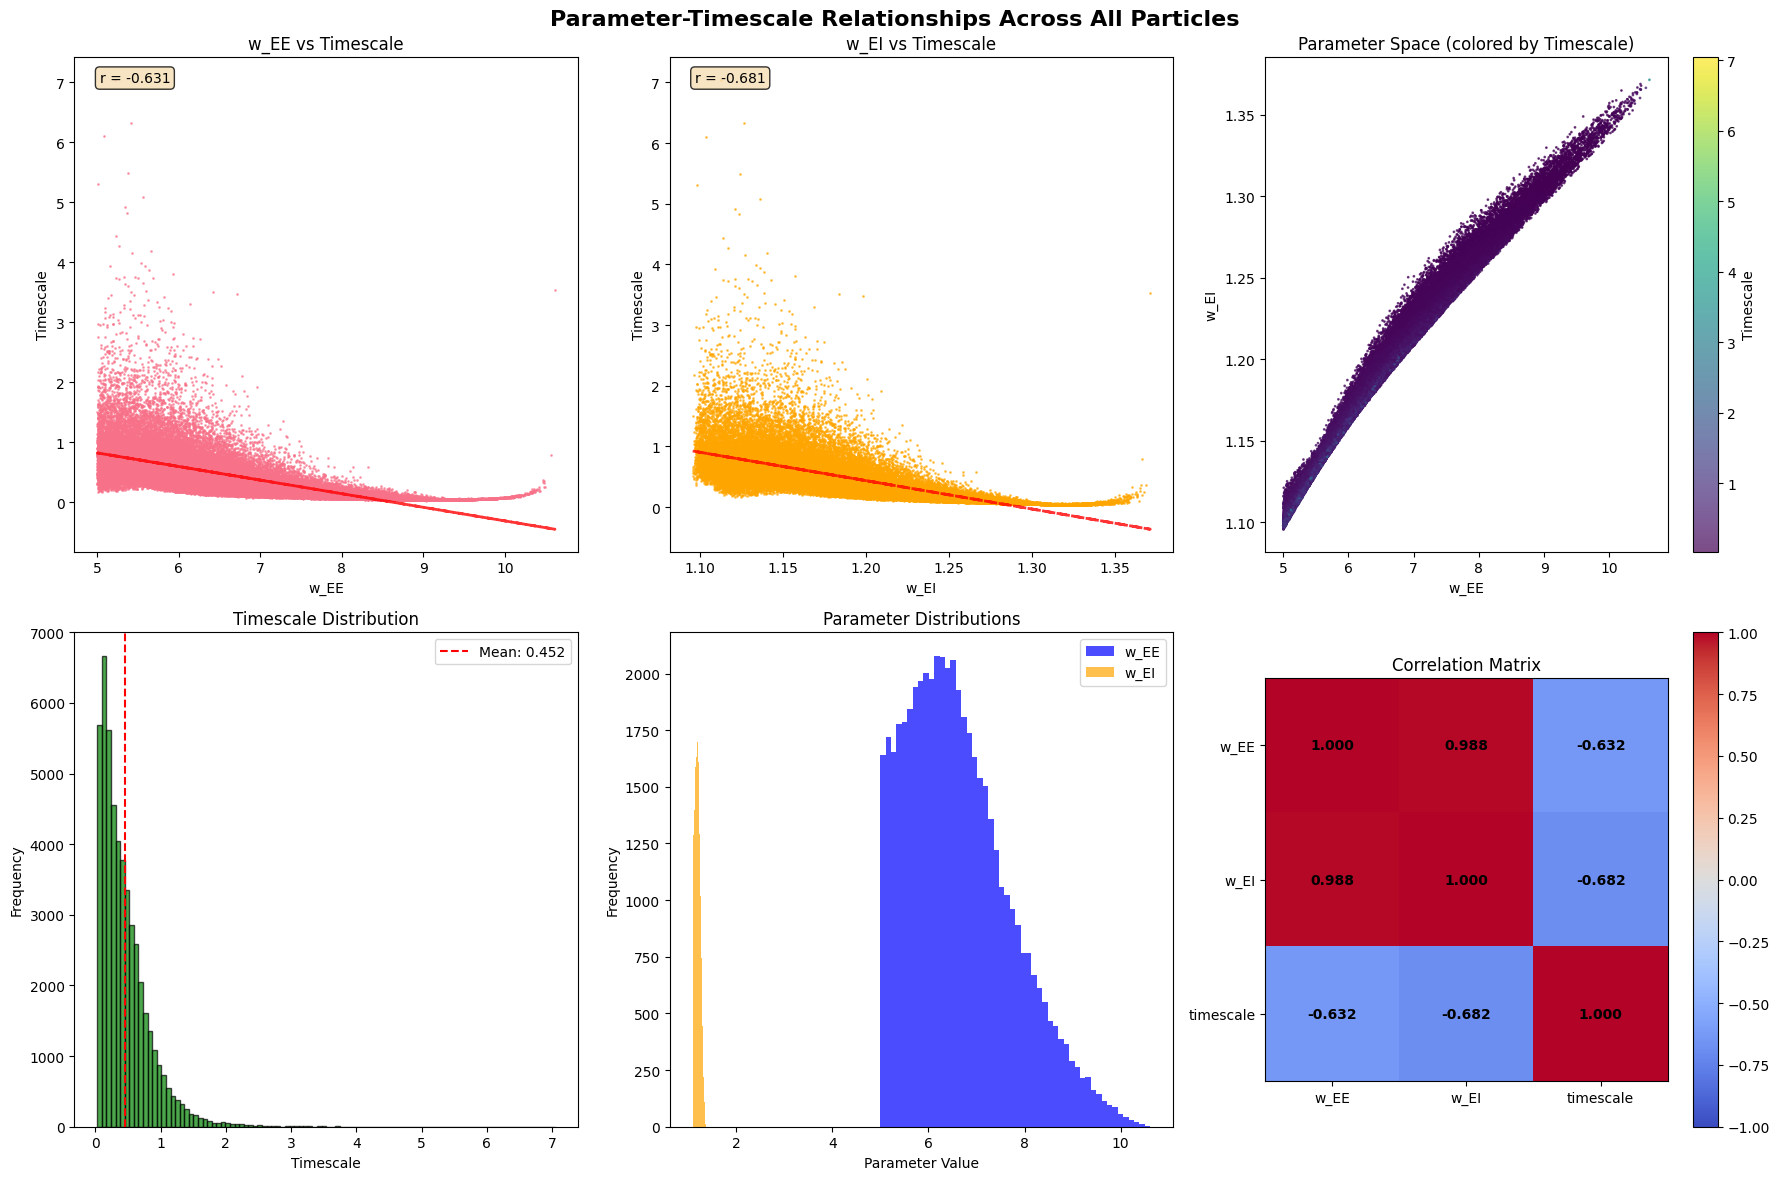

\n============================================================
PARAMETER-TIMESCALE RELATIONSHIP SUMMARY
Total data points: 142,418
Unique particles: 1000

Correlations with Timescale:
w_EE - Timescale: -0.6311
w_EI - Timescale: -0.6808

Parameter ranges:
w_EE: 5.000 - 10.625
w_EI: 1.096 - 1.374
Timescale: 0.031 - 7.043
Plots saved to /home/frank/HBNM/outputs/parameter_timescale_relationships.png
Correlation matrix saved to /home/frank/HBNM/outputs/correlation_matrix.csv

Analysis complete! You now have:
1. Comprehensive dataset of parameter-timescale relationships
2. Statistical analysis and visualizations
3. Saved data and plots for future reference


<Figure size 640x480 with 0 Axes>

In [47]:
# Generate comprehensive visualizations
print("Creating parameter-timescale relationship plots...")

# Create the comprehensive plots
correlation_matrix = plot_parameter_timescale_relationships(df, sample_size=50000)

# Save the plots
plt.savefig('/home/frank/HBNM/outputs/parameter_timescale_relationships.png', 
           dpi=300, bbox_inches='tight')
print("Plots saved to /home/frank/HBNM/outputs/parameter_timescale_relationships.png")

# Save correlation matrix as well
correlation_matrix.to_csv('/home/frank/HBNM/outputs/correlation_matrix.csv')
print("Correlation matrix saved to /home/frank/HBNM/outputs/correlation_matrix.csv")

print("\nAnalysis complete! You now have:")
print("1. Comprehensive dataset of parameter-timescale relationships")
print("2. Statistical analysis and visualizations") 
print("3. Saved data and plots for future reference")


In [52]:
# Debug: Check actual parameter values averaged across regions for each network using parcellation_df
test_particle = 0  # Use particle 0 instead of 100 to avoid index errors

import pandas as pd

# Load the parcellation dataframe if not already loaded
parcellation_path = "/home/frank/HBNM/data/parcellation_df_L.csv"
parcellation_df = pd.read_csv(parcellation_path)

# Use the same parameter set selected in the parameter selection cell
theta_debug = theta_selected
param_type_debug = detect_parameter_type(theta_debug)

model = Bnm(sc, gradient=hmap, map_invert_flags=[True])

print("Parameter debugging:")
print(f"Parameter type: {param_type_debug}")

# Set parameters based on type
if param_type_debug == 'homogeneous':
    model.set('w_EI', (theta_debug[0, test_particle], ))
    model.set('w_EE', (theta_debug[1, test_particle], ))
    model.set('G', (theta_debug[2, test_particle], ))
    print(f"w_EI: {theta_debug[0, test_particle]:.4f}")
    print(f"w_EE: {theta_debug[1, test_particle]:.4f}")
    print(f"G: {theta_debug[2, test_particle]:.4f}")
elif param_type_debug == 'heterogeneous':
    model.set('w_EI', (theta_debug[0, test_particle], theta_debug[1, test_particle]))
    model.set('w_EE', (theta_debug[2, test_particle], theta_debug[3, test_particle]))
    model.set('G', (theta_debug[4, test_particle], ))
    print(f"w_EI_bias: {theta_debug[0, test_particle]:.4f}")
    print(f"w_EI_coeff: {theta_debug[1, test_particle]:.4f}")
    print(f"w_EE_bias: {theta_debug[2, test_particle]:.4f}")
    print(f"w_EE_coeff: {theta_debug[3, test_particle]:.4f}")
    print(f"G: {theta_debug[4, test_particle]:.4f}")

model.moments_method

# Define canonical networks of interest
networks_of_interest = [
    'Visual1', 'Visual2', 'Somatomotor', 'Auditory', 'Dorsal-attention',
    'Language', 'Frontoparietal', 'Default'
]

# Compute fixed point and Jacobian
fixed_point = find_fixed_point(model)
J = compute_jacobian(model)

# Eigen analysis
eigen_results = eigen_analysis(J)

# Check stability
if not eigen_results['is_stable']:
    print("Unstable particle detected, skipping timescale computation.")
else:
    # Compute timescales
    regional_timescales, modal_timescales = compute_excitatory_timescales(
        eigen_results['eigenvalues'], 
        eigen_results['eigenvectors']
    )

    # Create comprehensive table with parameters and timescales for each network
    network_results = []
    
    for net in networks_of_interest:
        match = parcellation_df[parcellation_df['NetworkName'] == net]
        if not match.empty:
            indices = match.index.values
            
            # Compute averages
            avg_w_EE = model.dmf.w_EE[indices].mean()
            avg_w_EI = model.dmf.w_EI[indices].mean()
            avg_timescale = regional_timescales[indices].mean()
            n_regions = len(indices)
            
            network_results.append({
                'Network': net,
                'N_regions': n_regions,
                'avg_w_EE': avg_w_EE,
                'avg_w_EI': avg_w_EI,
                'avg_timescale': avg_timescale
            })
        else:
            network_results.append({
                'Network': net,
                'N_regions': 0,
                'avg_w_EE': np.nan,
                'avg_w_EI': np.nan,
                'avg_timescale': np.nan
            })
    
    # Create DataFrame for easy viewing
    results_df = pd.DataFrame(network_results)
    
    # Display nicely formatted table
    print("\n")
    print("NETWORK PARAMETERS AND TIMESCALES SUMMARY")
    # print("="*80)
    print(f"{'Network':<15} {'N_reg':<6} {'w_EE':<8} {'w_EI':<8} {'Timescale':<10}")
    print("-" * 60)
    
    for _, row in results_df.iterrows():
        if row['N_regions'] > 0:
            print(f"{row['Network']:<15} {int(row['N_regions']):<6} {row['avg_w_EE']:<8.4f} {row['avg_w_EI']:<8.4f} {row['avg_timescale']:<10.4f}")
        else:
            print(f"{row['Network']:<15} {'0':<6} {'N/A':<8} {'N/A':<8} {'N/A':<10}")
    
    print("\nDetailed DataFrame:")
    display(results_df.round(4))

Parameter debugging:
Parameter type: heterogeneous
w_EI_bias: 1.0201
w_EI_coeff: 0.1893
w_EE_bias: 3.9120
w_EE_coeff: 2.6352
G: 0.0922


NETWORK PARAMETERS AND TIMESCALES SUMMARY
Network         N_reg  w_EE     w_EI     Timescale 
------------------------------------------------------------
Visual1         3      4.5732   1.0676   0.8477    
Visual2         27     4.4748   1.0605   0.9922    
Somatomotor     19     4.8127   1.0848   0.7657    
Auditory        8      4.4545   1.0590   0.5301    
Dorsal-attention 12     5.2904   1.1191   0.9161    
Language        14     5.5355   1.1367   0.6619    
Frontoparietal  22     5.6052   1.1417   0.5759    
Default         40     5.7386   1.1513   0.4962    

Detailed DataFrame:


,Network,N_regions,avg_w_EE,avg_w_EI,avg_timescale
0,Visual1,3,4.5732,1.0676,0.8477
1,Visual2,27,4.4748,1.0605,0.9922
2,Somatomotor,19,4.8127,1.0848,0.7657
3,Auditory,8,4.4545,1.0590,0.5301
4,Dorsal-attention,12,5.2904,1.1191,0.9161
5,Language,14,5.5355,1.1367,0.6619
6,Frontoparietal,22,5.6052,1.1417,0.5759
7,Default,40,5.7386,1.1513,0.4962


In [68]:
# Debug: Check actual parameter values averaged across regions for each network using parcellation_df

import pandas as pd

# Load the parcellation dataframe if not already loaded
parcellation_path = "/home/frank/HBNM/data/parcellation_df_L.csv"
parcellation_df = pd.read_csv(parcellation_path)

# Use the same parameter set selected in the parameter selection cell
theta_debug = theta_selected
param_type_debug = detect_parameter_type(theta_debug)

# --- Filter for particles with w_EE_bias + w_EE_coef < 5 (only for heterogeneous) ---
if param_type_debug == 'heterogeneous':
    # Find all particles that satisfy the condition
    w_EE_bias = theta_debug[2, :]
    w_EE_coef = theta_debug[3, :]
    valid_particles = np.where((w_EE_bias + w_EE_coef) < 7)[0]
    if len(valid_particles) == 0:
        raise ValueError("No particles found with w_EE_bias + w_EE_coef < 5.")
    test_particle = valid_particles[0]
    print(f"Selected test_particle: {test_particle} (w_EE_bias + w_EE_coef = {w_EE_bias[test_particle] + w_EE_coef[test_particle]:.4f})")
else:
    test_particle = 0  # Use particle 0 for homogeneous

model = Bnm(sc, gradient=hmap, map_invert_flags=[True])

print("Parameter debugging:")
print(f"Parameter type: {param_type_debug}")

# Set parameters based on type
if param_type_debug == 'homogeneous':
    model.set('w_EI', (theta_debug[0, test_particle], ))
    model.set('w_EE', (theta_debug[1, test_particle], ))
    model.set('G', (theta_debug[2, test_particle], ))
    print(f"w_EI: {theta_debug[0, test_particle]:.4f}")
    print(f"w_EE: {theta_debug[1, test_particle]:.4f}")
    print(f"G: {theta_debug[2, test_particle]:.4f}")
elif param_type_debug == 'heterogeneous':
    model.set('w_EI', (theta_debug[0, test_particle], theta_debug[1, test_particle]))
    model.set('w_EE', (theta_debug[2, test_particle], theta_debug[3, test_particle]))
    model.set('G', (theta_debug[4, test_particle], ))
    print(f"w_EI_bias: {theta_debug[0, test_particle]:.4f}")
    print(f"w_EI_coef: {theta_debug[1, test_particle]:.4f}")
    print(f"w_EE_bias: {theta_debug[2, test_particle]:.4f}")
    print(f"w_EE_coef: {theta_debug[3, test_particle]:.4f}")
    print(f"G: {theta_debug[4, test_particle]:.4f}")

model.moments_method

# Define canonical networks of interest
networks_of_interest = [
    'Visual1', 'Visual2', 'Somatomotor', 'Auditory', 'Dorsal-attention',
    'Language', 'Frontoparietal', 'Default'
]

# Compute fixed point and Jacobian
fixed_point = find_fixed_point(model)
J = compute_jacobian(model)

# Eigen analysis
eigen_results = eigen_analysis(J)

# Check stability
if not eigen_results['is_stable']:
    print("Unstable particle detected, skipping timescale computation.")
else:
    # Compute timescales
    regional_timescales, modal_timescales = compute_excitatory_timescales(
        eigen_results['eigenvalues'], 
        eigen_results['eigenvectors']
    )

    # Create comprehensive table with parameters and timescales for each network
    network_results = []
    
    for net in networks_of_interest:
        match = parcellation_df[parcellation_df['NetworkName'] == net]
        if not match.empty:
            indices = match.index.values
            
            # Compute averages
            avg_w_EE = model.dmf.w_EE[indices].mean()
            avg_w_EI = model.dmf.w_EI[indices].mean()
            avg_timescale = regional_timescales[indices].mean()
            n_regions = len(indices)
            
            network_results.append({
                'Network': net,
                'N_regions': n_regions,
                'avg_w_EE': avg_w_EE,
                'avg_w_EI': avg_w_EI,
                'avg_timescale': avg_timescale
            })
        else:
            network_results.append({
                'Network': net,
                'N_regions': 0,
                'avg_w_EE': np.nan,
                'avg_w_EI': np.nan,
                'avg_timescale': np.nan
            })
    
    # Create DataFrame for easy viewing
    results_df = pd.DataFrame(network_results)
    
    # Display nicely formatted table
    print("\n")
    print("NETWORK PARAMETERS AND TIMESCALES SUMMARY")
    # print("="*80)
    print(f"{'Network':<15} {'N_reg':<6} {'w_EE':<8} {'w_EI':<8} {'Timescale':<10}")
    print("-" * 60)
    
    for _, row in results_df.iterrows():
        if row['N_regions'] > 0:
            print(f"{row['Network']:<15} {int(row['N_regions']):<6} {row['avg_w_EE']:<8.4f} {row['avg_w_EI']:<8.4f} {row['avg_timescale']:<10.4f}")
        else:
            print(f"{row['Network']:<15} {'0':<6} {'N/A':<8} {'N/A':<8} {'N/A':<10}")
    
    print("\nDetailed DataFrame:")
    display(results_df.round(4))

Selected test_particle: 0 (w_EE_bias + w_EE_coef = 6.5472)
Parameter debugging:
Parameter type: heterogeneous
w_EI_bias: 1.0201
w_EI_coef: 0.1893
w_EE_bias: 3.9120
w_EE_coef: 2.6352
G: 0.0922


NETWORK PARAMETERS AND TIMESCALES SUMMARY
Network         N_reg  w_EE     w_EI     Timescale 
------------------------------------------------------------
Visual1         3      4.5732   1.0676   0.8477    
Visual2         27     4.4748   1.0605   0.9922    
Somatomotor     19     4.8127   1.0848   0.7657    
Auditory        8      4.4545   1.0590   0.5301    
Dorsal-attention 12     5.2904   1.1191   0.9161    
Language        14     5.5355   1.1367   0.6619    
Frontoparietal  22     5.6052   1.1417   0.5759    
Default         40     5.7386   1.1513   0.4962    

Detailed DataFrame:


,Network,N_regions,avg_w_EE,avg_w_EI,avg_timescale
0,Visual1,3,4.5732,1.0676,0.8477
1,Visual2,27,4.4748,1.0605,0.9922
2,Somatomotor,19,4.8127,1.0848,0.7657
3,Auditory,8,4.4545,1.0590,0.5301
4,Dorsal-attention,12,5.2904,1.1191,0.9161
5,Language,14,5.5355,1.1367,0.6619
6,Frontoparietal,22,5.6052,1.1417,0.5759
7,Default,40,5.7386,1.1513,0.4962


In [32]:
# Quick Test: Verify Both Parameter Types Work
# =============================================
# This cell demonstrates that both parameter types work correctly

print("Testing both parameter types with a single particle...")
test_particle_id = 0

for param_name, theta_test in [("homogeneous", theta_homogeneous), ("heterogeneous", theta_heterogeneous)]:
    try:
        print(f"\\nTesting {param_name} parameters:")
        print(f"Parameter shape: {theta_test.shape}")
        
        # Test parameter detection
        detected_type = detect_parameter_type(theta_test)
        print(f"Detected type: {detected_type}")
        
        # Test model creation and parameter setting
        model = Bnm(sc, gradient=hmap, map_invert_flags=[True])
        
        if detected_type == 'homogeneous':
            model.set('w_EI', (theta_test[0, test_particle_id], ))
            model.set('w_EE', (theta_test[1, test_particle_id], ))
            model.set('G', (theta_test[2, test_particle_id], ))
            print(f"Set parameters: w_EI={theta_test[0, test_particle_id]:.4f}, w_EE={theta_test[1, test_particle_id]:.4f}, G={theta_test[2, test_particle_id]:.4f}")
        elif detected_type == 'heterogeneous':
            model.set('w_EI', (theta_test[0, test_particle_id], theta_test[1, test_particle_id]))
            model.set('w_EE', (theta_test[2, test_particle_id], theta_test[3, test_particle_id]))
            model.set('G', (theta_test[4, test_particle_id], ))
            print(f"Set parameters: w_EI=({theta_test[0, test_particle_id]:.4f}, {theta_test[1, test_particle_id]:.4f}), w_EE=({theta_test[2, test_particle_id]:.4f}, {theta_test[3, test_particle_id]:.4f}), G={theta_test[4, test_particle_id]:.4f}")
        
        model.moments_method
        
        # Test that we can extract parameter values
        w_EE_sample = model.dmf.w_EE[:5]  # First 5 regions
        w_EI_sample = model.dmf.w_EI[:5]  # First 5 regions
        print(f"Sample w_EE values: {w_EE_sample}")
        print(f"Sample w_EI values: {w_EI_sample}")
        print(f"✓ {param_name.capitalize()} parameters work correctly!")
        
    except Exception as e:
        print(f"✗ Error with {param_name} parameters: {str(e)}")

print("\\n" + "="*50)
print("Both parameter types are ready for analysis!")
print("Change 'theta_selected' in the parameter selection cell to switch between them.")
print("="*50)


Testing both parameter types with a single particle...
\nTesting homogeneous parameters:
Parameter shape: (4, 1000)
Detected type: homogeneous
Set parameters: w_EI=1.5539, w_EE=9.3877, G=9.9749
Sample w_EE values: [9.38773224 9.38773224 9.38773224 9.38773224 9.38773224]
Sample w_EI values: [1.55385285 1.55385285 1.55385285 1.55385285 1.55385285]
✓ Homogeneous parameters work correctly!
\nTesting heterogeneous parameters:
Parameter shape: (6, 1000)
Detected type: heterogeneous
Set parameters: w_EI=(1.0201, 0.1893), w_EE=(3.9120, 2.6352), G=0.0922
Sample w_EE values: [3.97301826 4.05162514 4.05178518 4.05290627 4.1294992 ]
Sample w_EI values: [1.02445046 1.03009825 1.03010975 1.0301903  1.0356934 ]
✓ Heterogeneous parameters work correctly!
\n==================================================
Both parameter types are ready for analysis!
Change 'theta_selected' in the parameter selection cell to switch between them.
